In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

In [3]:
train_df = pd.read_csv("train_energy_data.csv")
test_df = pd.read_csv("test_energy_data.csv")

In [4]:
train_df.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


In [5]:
test_df.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,24563,15,4,28.52,Weekday,2865.57
1,Commercial,27583,56,23,23.07,Weekend,4283.80
2,Commercial,45313,4,44,33.56,Weekday,5067.83
3,Residential,41625,84,17,27.39,Weekend,4624.30
4,Residential,36720,58,47,17.08,Weekday,4820.59


## PreProcessing

In [7]:
train_df.isnull().sum()


Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64

In [8]:
test_df.isnull().sum()

Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64

In [9]:
train_df_encoded = pd.get_dummies(train_df, drop_first=True, dtype=int)
test_df_encoded = pd.get_dummies(test_df, drop_first=True, dtype=int)

In [10]:
train_df_encoded, test_df_encoded = train_df_encoded.align(test_df_encoded, join='inner', axis=1)

In [11]:
target_col = 'Energy Consumption'

In [12]:
X_train = train_df_encoded.drop(columns=[target_col]).values
y_train = train_df_encoded[target_col].values

X_test = test_df_encoded.drop(columns=[target_col]).values
y_test = test_df_encoded[target_col].values

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
X_train_scratch = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_scratch = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

##  Linear Regression (From Scratch)

In [ ]:
class LinearRegressionFromScratch:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.lr = learning_rate
        self.iterations = iterations
        self.theta = None
        self.cost_history = []

    def fit(self, X, y):
        m, n = X.shape
        self.theta = np.zeros(n)
        
        for _ in range(self.iterations):
            predictions = X.dot(self.theta)
            errors = predictions - y
            
            # Gradient Descent Update
            gradients = (1/m) * X.T.dot(errors)
            self.theta -= self.lr * gradients
            
            
            cost = (1/(2*m)) * np.sum(errors**2)
            self.cost_history.append(cost)

    def predict(self, X):
        return X.dot(self.theta)

In [16]:
model_scratch = LinearRegressionFromScratch(learning_rate=0.05, iterations=1500)
model_scratch.fit(X_train_scratch, y_train)

In [17]:
y_pred_scratch = model_scratch.predict(X_test_scratch)

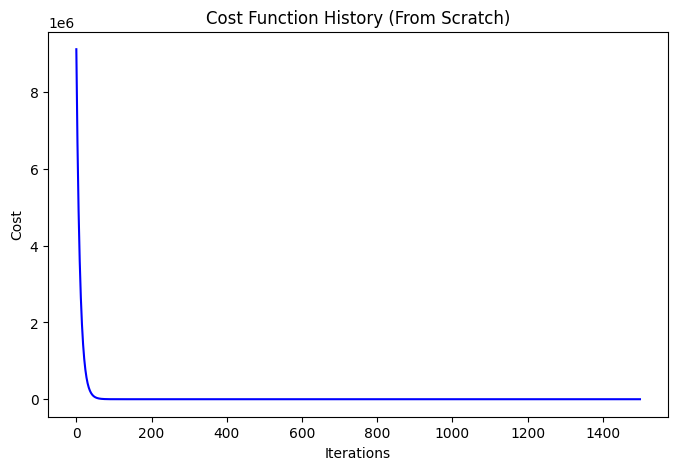

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(model_scratch.cost_history, color='blue')
plt.title("Cost Function History (From Scratch)")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()

##  Linear Regression (BuiltIn)

In [19]:
model_sklearn = LinearRegression()
model_sklearn.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ 714.37, 290.47, 281.96,..., 232.65,-238.01, -25. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4166
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,7
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](7,)","[38.77,32.83,32.16,...,31.03,30.38,22.33]"


In [20]:
y_pred_sklearn = model_sklearn.predict(X_test_scaled)

##  Evaluation and Comparison
- Mean Squared Error (MSE)
- Mean Absolute Error (MAE)
- R-squared (R2 Score)

In [21]:
def evaluate_model(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- {name} ---")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2 Score: {r2:.4f}\n")
    return [mse, mae, r2]

results_scratch = evaluate_model("Model (From Scratch)", y_test, y_pred_scratch)
results_sklearn = evaluate_model("Model (Scikit-Learn)", y_test, y_pred_sklearn)

--- Model (From Scratch) ---
MSE: 0.0002
MAE: 0.0122
R2 Score: 1.0000

--- Model (Scikit-Learn) ---
MSE: 0.0002
MAE: 0.0122
R2 Score: 1.0000



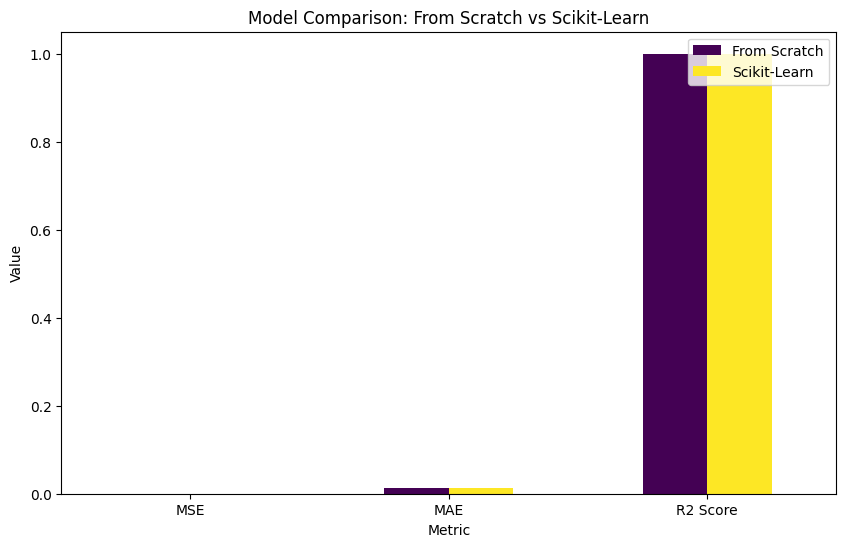

In [22]:
metrics_df = pd.DataFrame({
    'Metric': ['MSE', 'MAE', 'R2 Score'],
    'From Scratch': results_scratch,
    'Scikit-Learn': results_sklearn
})

metrics_df.set_index('Metric').plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title("Model Comparison: From Scratch vs Scikit-Learn")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.show()

## Save Model

In [23]:
joblib.dump(model_sklearn, 'linear_regression_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Saved Successfully")

Saved Successfully
